# Decision Trees in Python

In [ ]:
# Load libraries
import pandas as pd

# Import Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

# Import train_test_split function
from sklearn.model_selection import train_test_split

#Import scikit-learn metrics module for accuracy calculation
from sklearn import metrics

import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# load dataset
pima = pd.read_csv("diabetes.csv")

In [ ]:
pima.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
pima

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
pima['BMI'].value_counts()

,count
BMI,
32.0,13
31.6,12
31.2,12
0.0,11
32.4,10
...,...
36.7,1
41.8,1
42.6,1


In [ ]:
#split dataset in features and target variable
feature_cols = ['Pregnancies', 'Insulin', 'BMI', 'Age','Glucose','BloodPressure','SkinThickness','DiabetesPedigreeFunction']
X = pima[feature_cols] # Features
y = pima.Outcome # Target variable

In [ ]:
# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [ ]:
# Create Decision Tree classifer object
clf = DecisionTreeClassifier()

# Train Decision Tree Classifer
clf = clf.fit(X_train,y_train)

#Predict the response for test dataset
y_pred = clf.predict(X_test)

In [ ]:
# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.7186147186147186


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.80      0.76      0.78       150
           1       0.59      0.64      0.62        81

    accuracy                           0.72       231
   macro avg       0.69      0.70      0.70       231
weighted avg       0.72      0.72      0.72       231



## Optimizing Decision Tree Performance

In [ ]:
# Create Decision Tree classifer object
clf1 = DecisionTreeClassifier(max_depth=4, splitter="random")

# Train Decision Tree Classifer
clf1 = clf1.fit(X_train,y_train)

#Predict the response for test dataset
y_pred = clf1.predict(X_test)

# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.7402597402597403


In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.75      0.88      0.81       150
           1       0.67      0.44      0.53        81

    accuracy                           0.73       231
   macro avg       0.71      0.66      0.67       231
weighted avg       0.72      0.73      0.71       231



In [ ]:
from sklearn import tree

[Text(0.4791666666666667, 0.9, 'x[4] <= 108.784\ngini = 0.454\nsamples = 537\nvalue = [350, 187]'),
 Text(0.2708333333333333, 0.7, 'x[2] <= 38.609\ngini = 0.242\nsamples = 213\nvalue = [183, 30]'),
 Text(0.16666666666666666, 0.5, 'x[7] <= 0.471\ngini = 0.208\nsamples = 187\nvalue = [165, 22]'),
 Text(0.08333333333333333, 0.3, 'x[0] <= 9.536\ngini = 0.113\nsamples = 116\nvalue = [109, 7]'),
 Text(0.041666666666666664, 0.1, 'gini = 0.089\nsamples = 107\nvalue = [102, 5]'),
 Text(0.125, 0.1, 'gini = 0.346\nsamples = 9\nvalue = [7, 2]'),
 Text(0.25, 0.3, 'x[4] <= 104.471\ngini = 0.333\nsamples = 71\nvalue = [56, 15]'),
 Text(0.20833333333333334, 0.1, 'gini = 0.274\nsamples = 61\nvalue = [51, 10]'),
 Text(0.2916666666666667, 0.1, 'gini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.375, 0.5, 'x[4] <= 45.664\ngini = 0.426\nsamples = 26\nvalue = [18, 8]'),
 Text(0.3333333333333333, 0.3, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.4166666666666667, 0.3, 'x[7] <= 1.125\ngini = 0.375\nsa

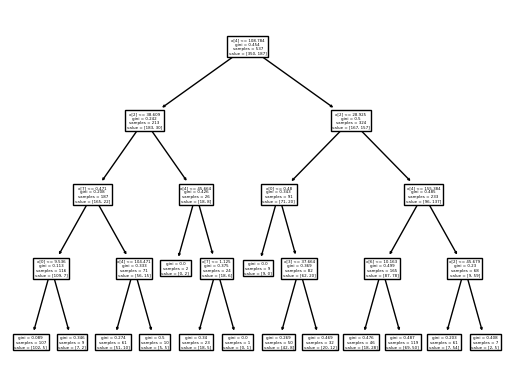

In [ ]:
tree.plot_tree(clf1)

[Text(0.4791666666666667, 0.9, 'Glucose <= 108.784\ngini = 0.454\nsamples = 537\nvalue = [350, 187]\nclass = O'),
 Text(0.2708333333333333, 0.7, 'BMI <= 38.609\ngini = 0.242\nsamples = 213\nvalue = [183, 30]\nclass = O'),
 Text(0.16666666666666666, 0.5, 'DiabetesPedigreeFunction <= 0.471\ngini = 0.208\nsamples = 187\nvalue = [165, 22]\nclass = O'),
 Text(0.08333333333333333, 0.3, 'Pregnancies <= 9.536\ngini = 0.113\nsamples = 116\nvalue = [109, 7]\nclass = O'),
 Text(0.041666666666666664, 0.1, 'gini = 0.089\nsamples = 107\nvalue = [102, 5]\nclass = O'),
 Text(0.125, 0.1, 'gini = 0.346\nsamples = 9\nvalue = [7, 2]\nclass = O'),
 Text(0.25, 0.3, 'Glucose <= 104.471\ngini = 0.333\nsamples = 71\nvalue = [56, 15]\nclass = O'),
 Text(0.20833333333333334, 0.1, 'gini = 0.274\nsamples = 61\nvalue = [51, 10]\nclass = O'),
 Text(0.2916666666666667, 0.1, 'gini = 0.5\nsamples = 10\nvalue = [5, 5]\nclass = O'),
 Text(0.375, 0.5, 'Glucose <= 45.664\ngini = 0.426\nsamples = 26\nvalue = [18, 8]\nclass 

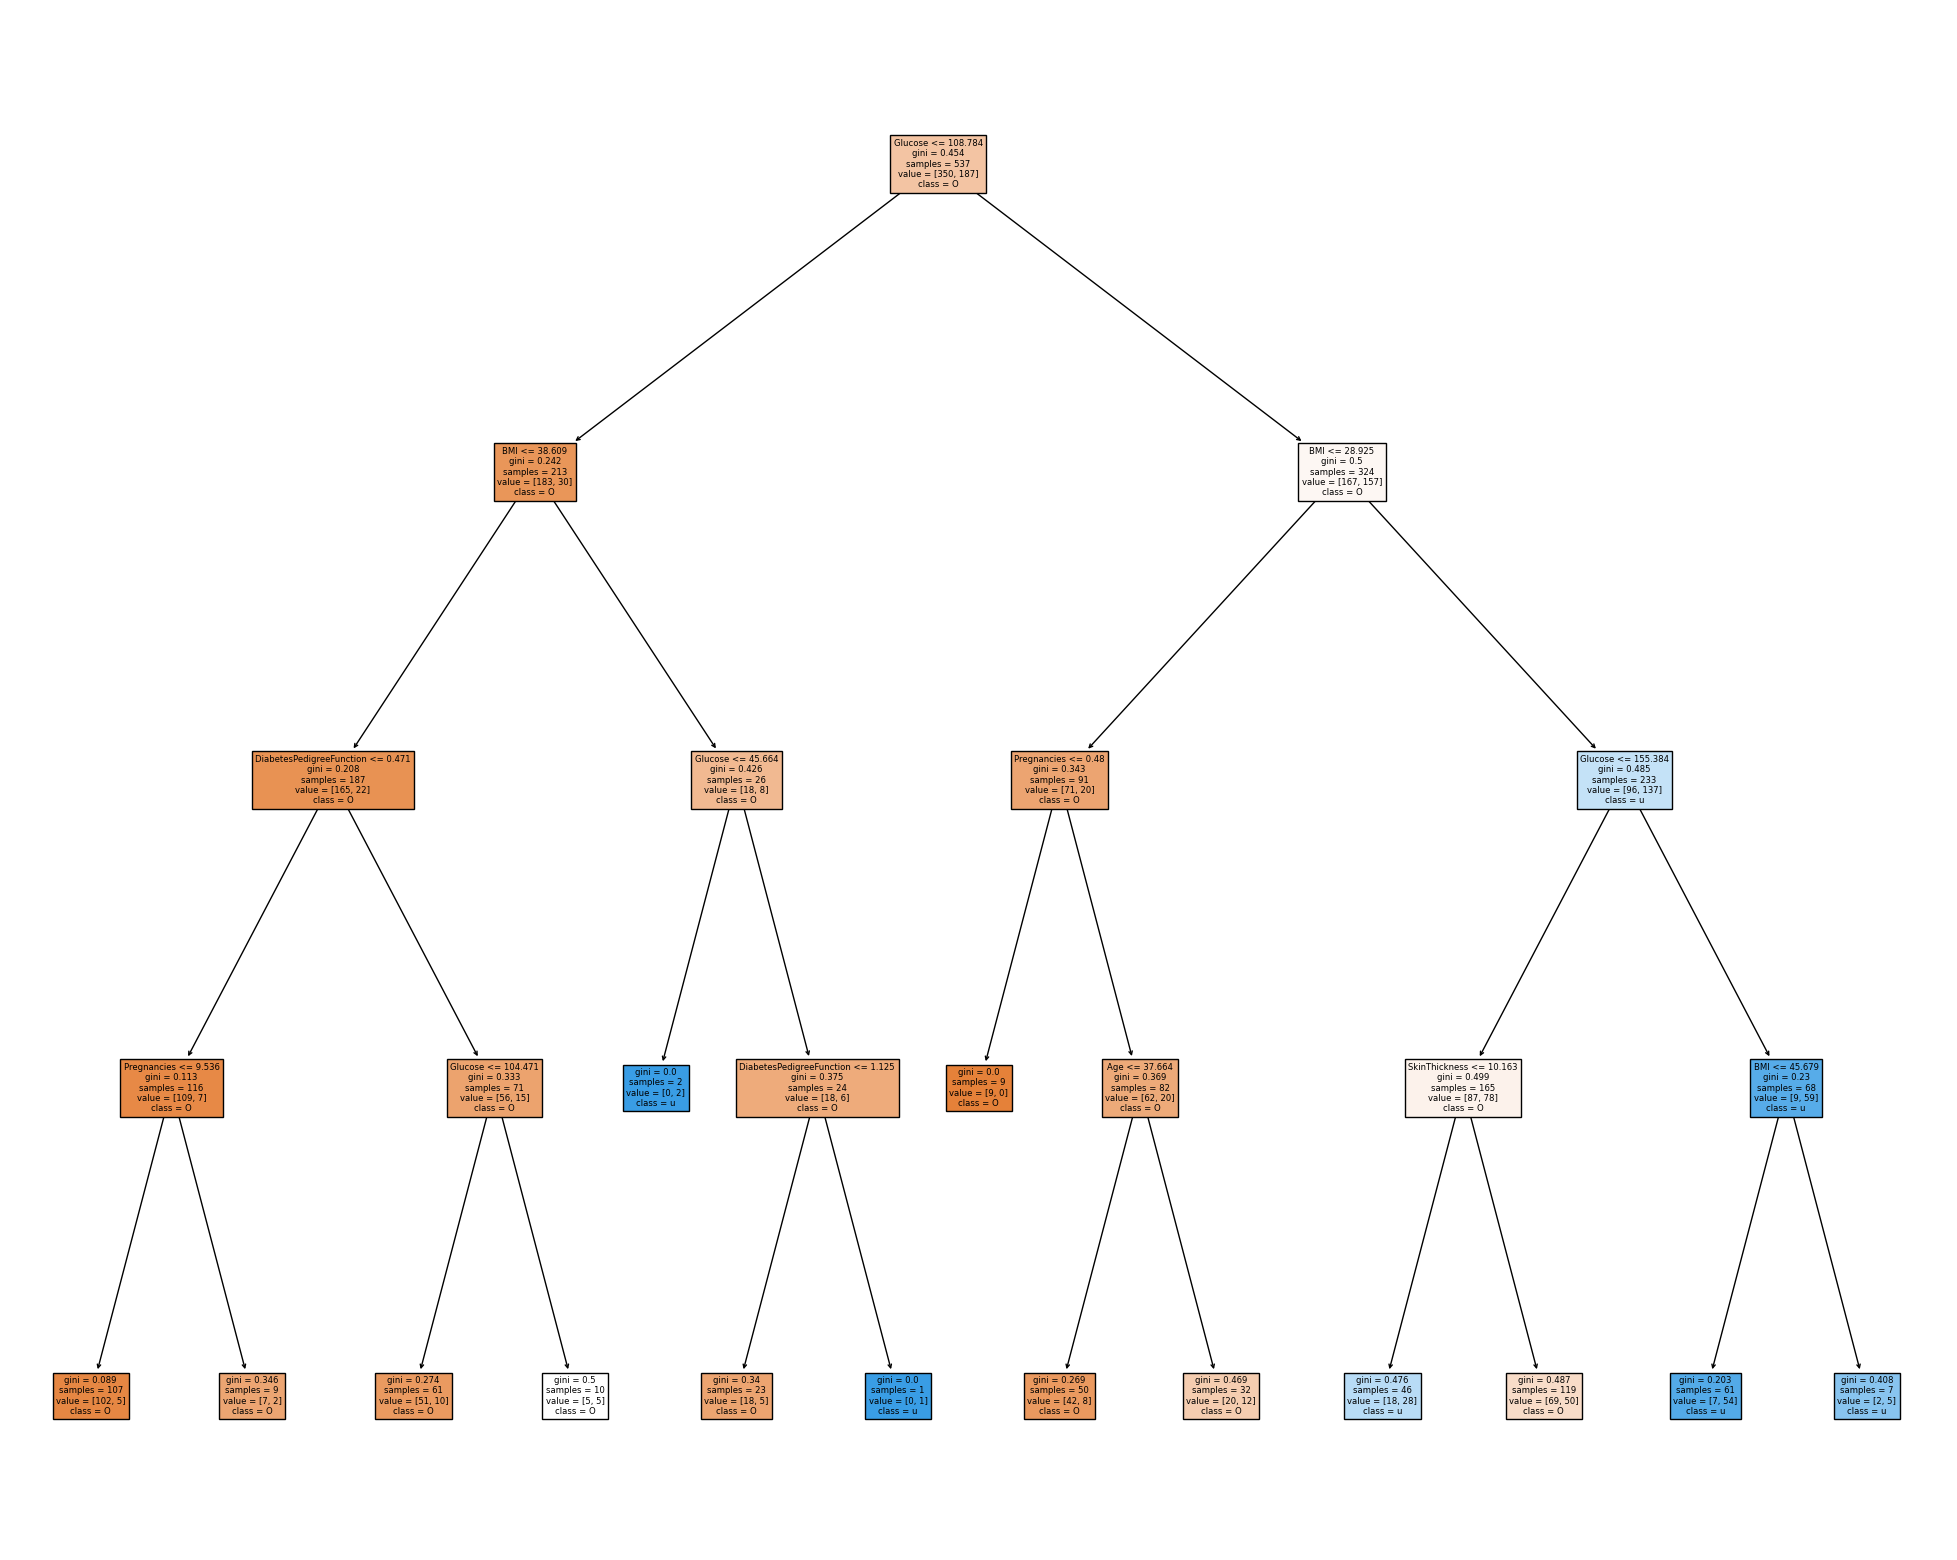

In [ ]:
fig = plt.figure(figsize=(25,20))
tree.plot_tree(clf1,
                   feature_names=feature_cols,
                   class_names='Outcome',
                   filled=True)
